<a href="https://colab.research.google.com/github/SohailVibeCoder/IB9AU---GenAI/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Sohail Essajee (U5757504)



An MLP's limitation lies in its flattening of images into a 784-pixel list, losing spatial relationships. Despite this, it achieves ~88% accuracy because clothing items exhibit consistent global pixel patterns. However, it struggles with distinctions like 'Shirt' vs. 'Pullover' where shape and structure, rather than just pixel values, are crucial for accurate classification.



**Task 4**




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuration
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

# 2. Define Transformations
# Normalize inputs for stable training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 3. Load Data
print("Downloading FashionMNIST Data...")
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                                  download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                                 download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Class names for FashionMNIST
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

print("Data Loaded Successfully!")

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.52MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 193kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.53MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.14MB/s]

Data Loaded Successfully!


**Define the MLP model**

In [ ]:
class ImageMLP(nn.Module):
    def __init__(self):
        super(ImageMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 512)  # Input layer to Hidden layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 10)       # Hidden layer to Output (10 classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Instantiate model, loss, and optimizer
model = ImageMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Model Defined.")

Model Defined.


**Train**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Training on {device}...")

loss_history = []

for epoch in range(EPOCHS):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

print("Training Finished.")

Training on cpu...
Epoch [1/10], Loss: 0.4762
Epoch [2/10], Loss: 0.3669
Epoch [3/10], Loss: 0.3292
Epoch [4/10], Loss: 0.3046
Epoch [5/10], Loss: 0.2859
Epoch [6/10], Loss: 0.2699
Epoch [7/10], Loss: 0.2575
Epoch [8/10], Loss: 0.2439
Epoch [9/10], Loss: 0.2328
Epoch [10/10], Loss: 0.2218
Training Finished.


**Evaluate**

Accuracy on 10,000 test images: 88.15%


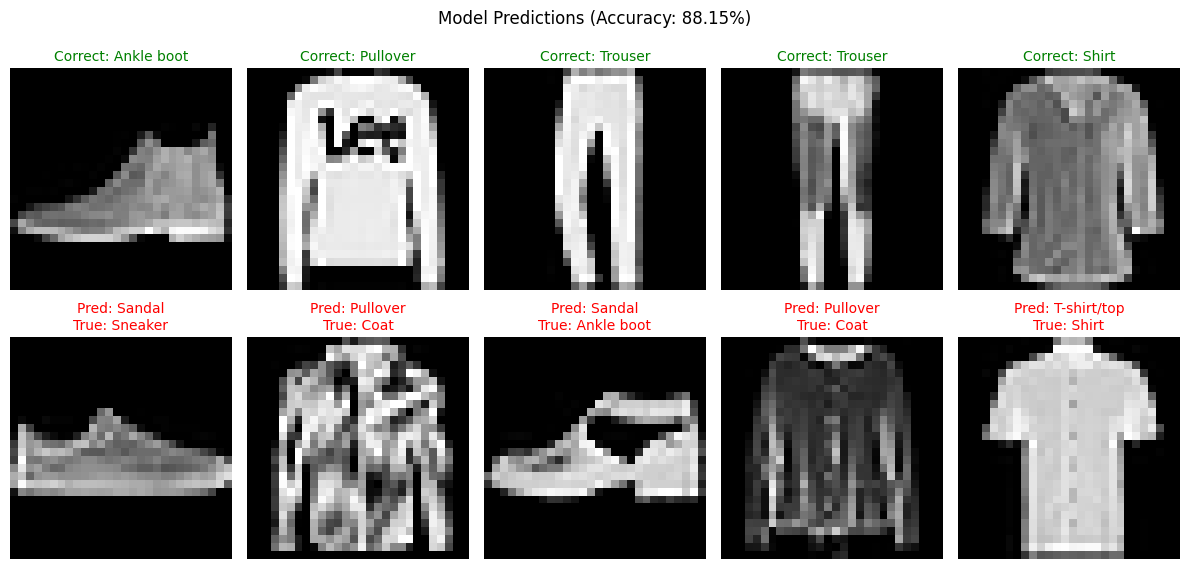

In [ ]:
model.eval()  # Set model to evaluation mode
correct = 0
total = 0
all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store data for visualization
        all_images.extend(images.cpu())
        all_preds.extend(predicted.cpu())
        all_labels.extend(labels.cpu())

accuracy = 100 * correct / total
print(f'Accuracy on 10,000 test images: {accuracy:.2f}%')

# --- Visualization ---
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')

# Plot 5 Correct and 5 Incorrect
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle(f"Model Predictions (Accuracy: {accuracy:.2f}%)")

correct_indices = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p == l]
incorrect_indices = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]

# Row 1: Correct Predictions
for i in range(5):
    idx = correct_indices[i]
    ax = axes[0, i]
    plt.sca(ax)
    imshow(all_images[idx])
    ax.set_title(f"Correct: {classes[all_preds[idx]]}", color="green", fontsize=10)
    ax.axis('off')

# Row 2: Incorrect Predictions
for i in range(5):
    idx = incorrect_indices[i]
    ax = axes[1, i]
    plt.sca(ax)
    imshow(all_images[idx])
    # Show Predicted vs True
    title = f"Pred: {classes[all_preds[idx]]}\nTrue: {classes[all_labels[idx]]}"
    ax.set_title(title, color="red", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()